# Analiza Intenției de Cumpărare Online prin Arbori de Decizie


## Descrierea Proiectului

Acest proiect aplică tehnici de **clasificare bazate pe arbori de decizie** pentru a analiza și prezice intenția de cumpărare a vizitatorilor unui site de e-commerce. Folosind datele de sesiune ale utilizatorilor, modelele construite identifică **pattern-uri comportamentale** care diferențiază vizitatorii care finalizează o achiziție de cei care nu o fac.

## Obiectiv

Variabila țintă este **`Revenue`** (calitativă, binară: `TRUE` / `FALSE`), care indică dacă o sesiune de navigare s-a finalizat cu o tranzacție comercială.

Scopul principal este construirea unor modele predictive capabile să clasifice corect intenția de cumpărare pe baza caracteristicilor comportamentale și tehnice ale sesiunii.

In [112]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [113]:
os.getcwd()

'/home/matei/Financial-Fraud-Detection/notebooks/OnlinePurchasing'

In [114]:
path_to_dataset = '../../data/raw/online_shoppers_intention_recoded.csv'

if not os.path.isfile(path_to_dataset):
    print("no good")
else:
    df = pd.read_csv(path_to_dataset)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  str    
 12  Browser                  12330 non-null  str    
 13  Region                   12330 non-null  str    
 14  TrafficType              12330 no

In [116]:
df.shape

(12330, 18)

-   Dimensiune: 12.330 înregistrări (linii), 18 variabile(coloane)

-   Sursă: UCI Machine Learning Repository / Kaggle.

-   Perioadă: Date colectate pe parcursul unui an pentru a evita bias-ul de sezonalitate (deși lipsesc Ianuarie și Aprilie).

## EDA

-   Valori lipsa

-   Valori unice

In [117]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              5
Browser                       9
Region                        9
TrafficType                  12
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [118]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

-   Duplicate

In [119]:
df.duplicated().sum()

np.int64(125)

In [120]:
df.shape[0]

12330

In [121]:
df = df.drop_duplicates()
df.shape[0]

12205

In [122]:

print(f"VisitorType valori: {df['VisitorType'].unique()}")
print(f"Weekend valori: {df['Weekend'].unique()}")
print(f"Revenue valori: {df['Revenue'].unique()}")
print(f"Month valori: {sorted(df['Month'].unique())}")

VisitorType valori: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str
Weekend valori: [False  True]
Revenue valori: [False  True]
Month valori: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


-   Obs: lipsesc Aprilie si Ianuarie

## Analiza nebalansarii claselor

In [123]:
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [124]:
counts = df['Revenue'].value_counts()
pcts = df['Revenue'].value_counts(normalize=True) * 100
 
print(f"Clasa FALSE (nu cumpără): {counts[False]:>6,} -> {pcts[False]:.2f}%")
print(f"Clasa TRUE (cumpără): {counts[True]:>6,} -> {pcts[True]:.2f}%")
print(f"Raport dezechilibru : {counts[False]/counts[True]:.1f} : 1")

Clasa FALSE (nu cumpără): 10,297 -> 84.37%
Clasa TRUE (cumpără):  1,908 -> 15.63%
Raport dezechilibru : 5.4 : 1


-   BD este nebalansata: clasa majoritara depaseste cu mult pe cea minoritara cu un raport de aprox 5.5:1. Dezechilibru mare, care poate duce la modele care clasifica tot ca FALSE si totusi obtine acuratete mare, de sa zicem 84%

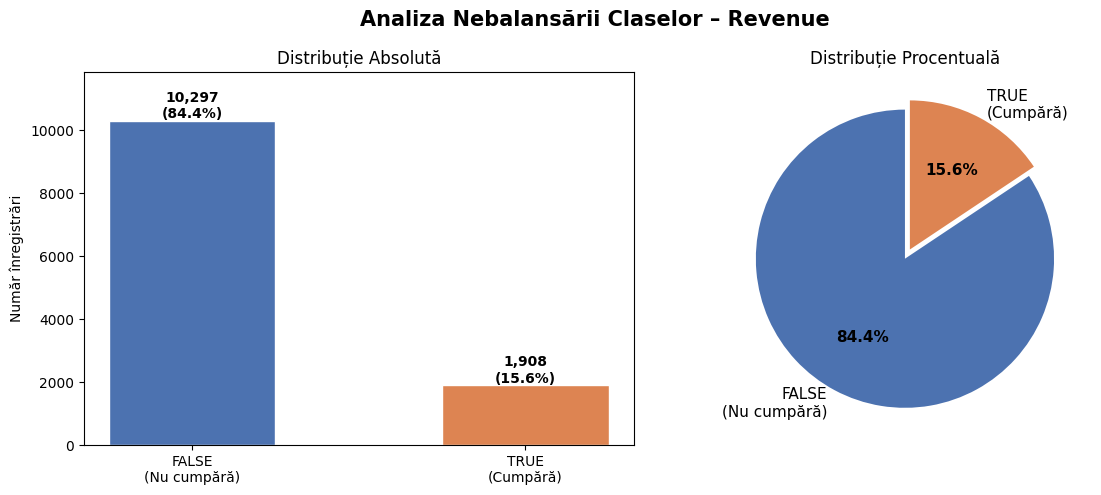

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analiza Nebalansării Claselor – Revenue', fontsize=15, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
            [counts[False], counts[True]],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribuție Absolută', fontsize=12)
axes[0].set_ylabel('Număr înregistrări')
for i, (v, p) in enumerate(zip([counts[False], counts[True]], [pcts[False], pcts[True]])):
    axes[0].text(i, v + 80, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylim(0, counts[False] * 1.15)

wedges, texts, autotexts = axes[1].pie(
    [counts[False], counts[True]],
    labels=['FALSE\n(Nu cumpără)', 'TRUE\n(Cumpără)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.07),
    textprops={'fontsize': 11}
)
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
axes[1].set_title('Distribuție Procentuală', fontsize=12)
 
plt.tight_layout()
plt.show()

Nebalansare

-   Date medii: 10k

-   Raport: 1:5.5

Din Fisa cu Nebalansare Date Mining, variantele recomandate sunt

-   SMOTE; ADASYN; SMOTE-Tomek; class weight

-   Indicatori recomandati: F1, G-MEAN, MCC, PR-AUC

In [126]:
#%pip install -U imbalanced-learn

In [127]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [128]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems               str
Browser                        str
Region                         str
TrafficType                    str
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [129]:
categ_variab = [col for col in df.columns if df[col].dtype == 'str']
categ_variab

['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType']

In [130]:
df_smote = df.copy()
df_smote['Weekend'] = df_smote['Weekend'].astype(int)

le_dict = {}
cat_cols = ['Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType']

for col in cat_cols:
    le = LabelEncoder()
    df_smote[col] = le.fit_transform(df_smote[col].astype(str))
    le_dict[col] = le

df_smote['Revenue'] = df_smote['Revenue'].astype(int)

X = df_smote.drop('Revenue', axis=1)
y = df_smote['Revenue']
 
smote = SMOTE(sampling_strategy=0.5, random_state=7, k_neighbors=5)
X_res, y_res = smote.fit_resample(X, y)

df_final = pd.DataFrame(X_res, columns=X.columns)
df_final['Revenue'] = y_res
 
print(f"Înainte de SMOTE: {dict(pd.Series(y).value_counts())}")
print(f"După SMOTE : {dict(pd.Series(y_res).value_counts())}")
print(f"Total înregistrări după SMOTE: {len(y_res):,}")


Înainte de SMOTE: {0: np.int64(10297), 1: np.int64(1908)}
După SMOTE : {0: np.int64(10297), 1: np.int64(5148)}
Total înregistrări după SMOTE: 15,445


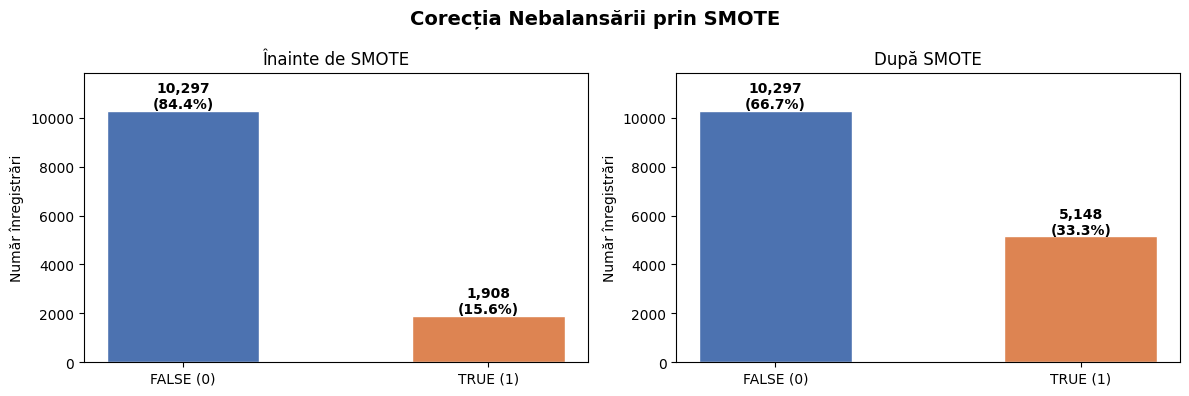

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Corecția Nebalansării prin SMOTE', fontsize=14, fontweight='bold')
 
before = pd.Series(y).value_counts()
after  = pd.Series(y_res).value_counts()
 
for ax, data, title in zip(axes, [before, after], ['Înainte de SMOTE', 'După SMOTE']):
    ax.bar(['FALSE (0)', 'TRUE (1)'], [data[0], data[1]], color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Număr înregistrări')
    for i, v in enumerate([data[0], data[1]]):
        pct = v / data.sum() * 100
        ax.text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(before[0], after[0]) * 1.15)
 
plt.tight_layout()
plt.show()

-   Dupa SMOTE, raport 1:2

## Outliers

In [132]:
df_smote.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object

In [133]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems               str
Browser                        str
Region                         str
TrafficType                    str
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [134]:
num_cols = ['Administrative', 'Administrative_Duration',
            'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [135]:
outlier_report = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'Lower': lower, 'Upper': upper,
                           'N_outliers': n_out, 'Pct': pct}
    print(f"  {col:<28} {Q1:>8.3f} {Q3:>8.3f} {IQR:>8.3f} {lower:>12.3f} {upper:>12.3f} {n_out:>10,} {pct:>5.1f}%")

  Administrative                  0.000    4.000    4.000       -6.000       10.000        404   3.3%
  Administrative_Duration         0.000   94.700   94.700     -142.050      236.750      1,149   9.4%
  Informational                   0.000    0.000    0.000        0.000        0.000      2,631  21.6%
  Informational_Duration          0.000    0.000    0.000        0.000        0.000      2,405  19.7%
  ProductRelated                  8.000   38.000   30.000      -37.000       83.000      1,007   8.3%
  ProductRelated_Duration       193.000 1477.155 1284.155    -1733.232     3403.387        951   7.8%
  BounceRates                     0.000    0.017    0.017       -0.025        0.042      1,428  11.7%
  ExitRates                       0.014    0.049    0.034       -0.037        0.100      1,325  10.9%
  PageValues                      0.000    0.000    0.000        0.000        0.000      2,730  22.4%
  SpecialDay                      0.000    0.000    0.000        0.000        0.00

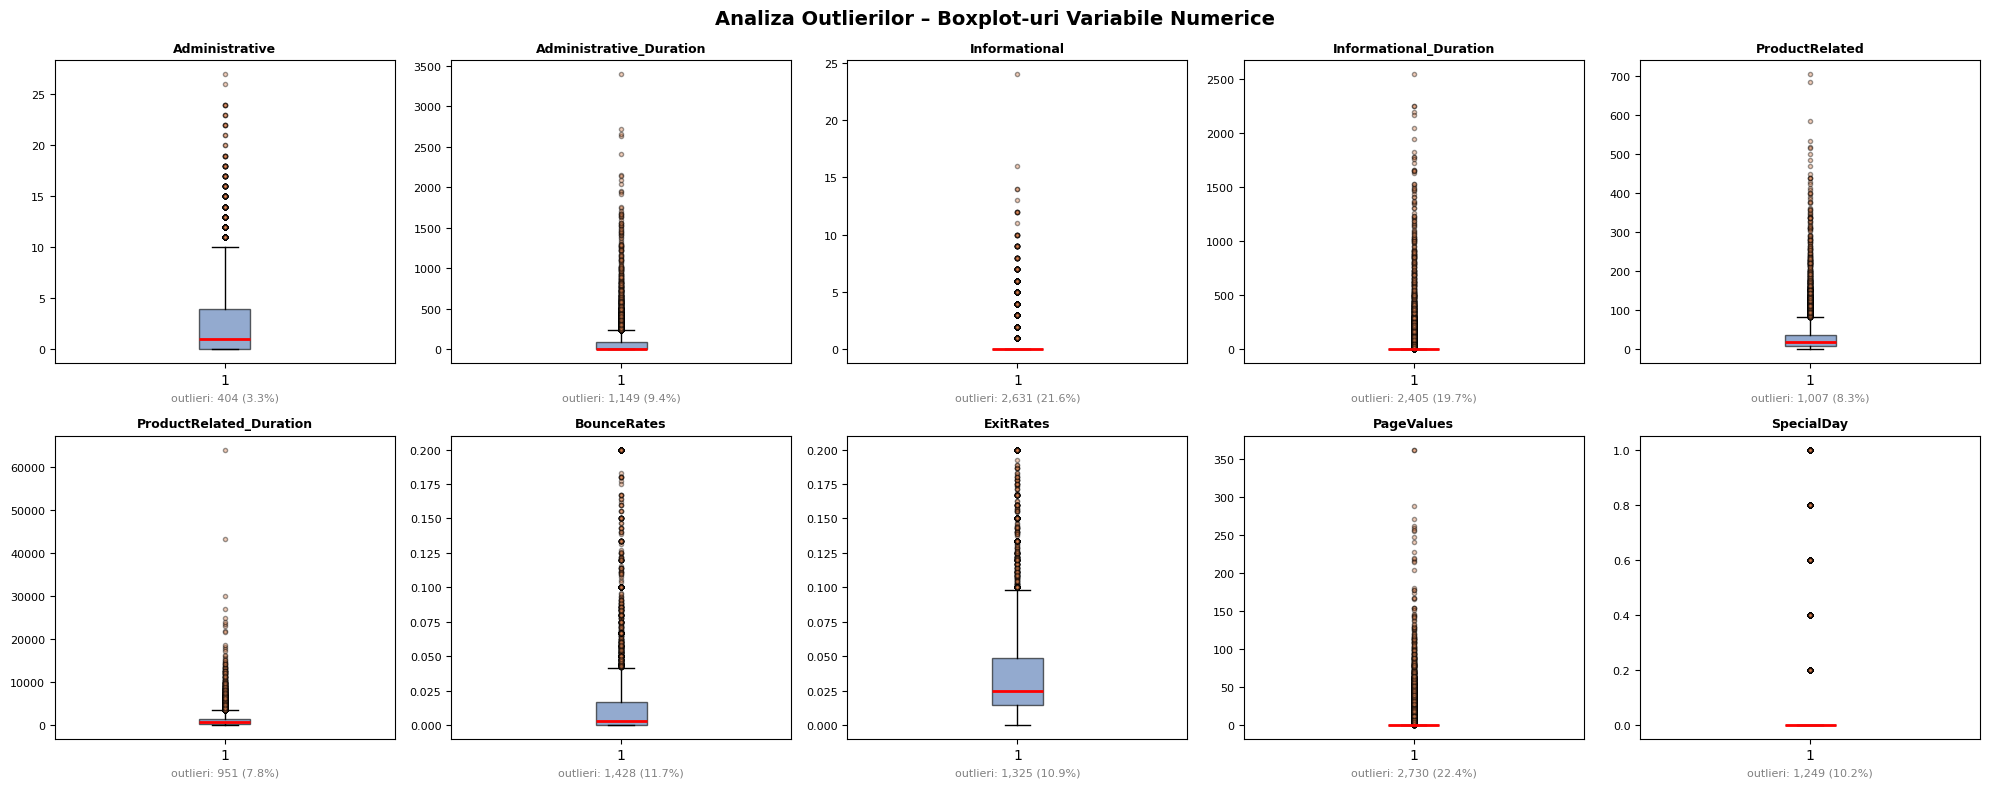

In [136]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Analiza Outlierilor – Boxplot-uri Variabile Numerice', fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#DD8452', markersize=3, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=8)
    n_out = outlier_report[col]['N_outliers']
    pct   = outlier_report[col]['Pct']
    axes[i].set_xlabel(f'outlieri: {n_out:,} ({pct:.1f}%)', fontsize=8, color='gray')
 
plt.tight_layout()
plt.show()

/tmp/ipykernel_24848/2233146710.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_f, data_t], labels=['FALSE\n(nu cumpără)', 'TRUE\n(cumpără)'],
/tmp/ipykernel_24848/2233146710.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_f, data_t], labels=['FALSE\n(nu cumpără)', 'TRUE\n(cumpără)'],
/tmp/ipykernel_24848/2233146710.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_f, data_t], labels=['FALSE\n(nu cumpără)', 'TRUE\n(cumpără)'],
/tmp/ipykernel_24848/2233146710.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels

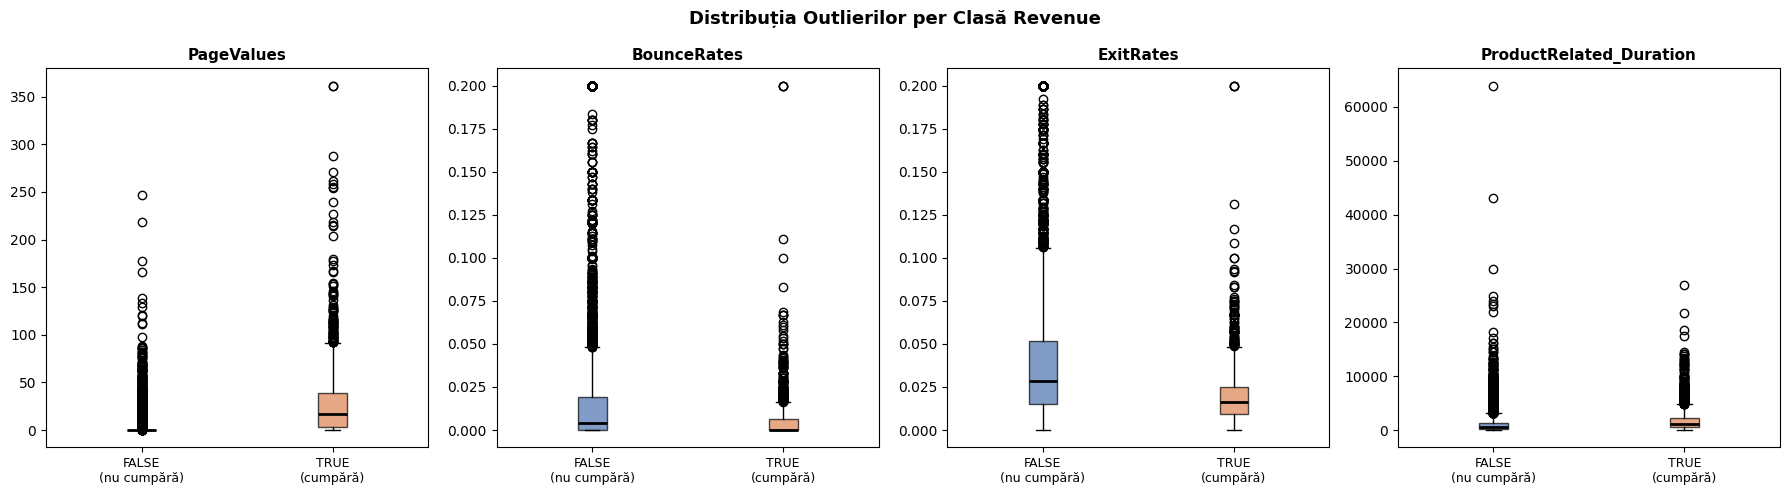

In [137]:
key_vars = ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated_Duration']
 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribuția Outlierilor per Clasă Revenue', fontsize=13, fontweight='bold')
 
for ax, col in zip(axes, key_vars):
    data_f = df[df['Revenue'] == False][col]
    data_t = df[df['Revenue'] == True][col]
    ax.boxplot([data_f, data_t], labels=['FALSE\n(nu cumpără)', 'TRUE\n(cumpără)'],
               patch_artist=True,
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    boxes = ax.patches
    if len(boxes) >= 2:
        boxes[0].set_facecolor('#4C72B0')
        boxes[1].set_facecolor('#DD8452')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
 
plt.tight_layout()
plt.show()

- Semantic valid — valorile extreme reflectă comportament real de navigare, nu erori de colectare

- Putere discriminantă — PageValues ridicat corelează direct cu Revenue=TRUE

- Discretizarea rezolvă problema — variabilele continue vor fi transformate în categorii, outlierii intrând automat în categoria "Mare/Lung" fără a distorsiona modelul

## Distributii

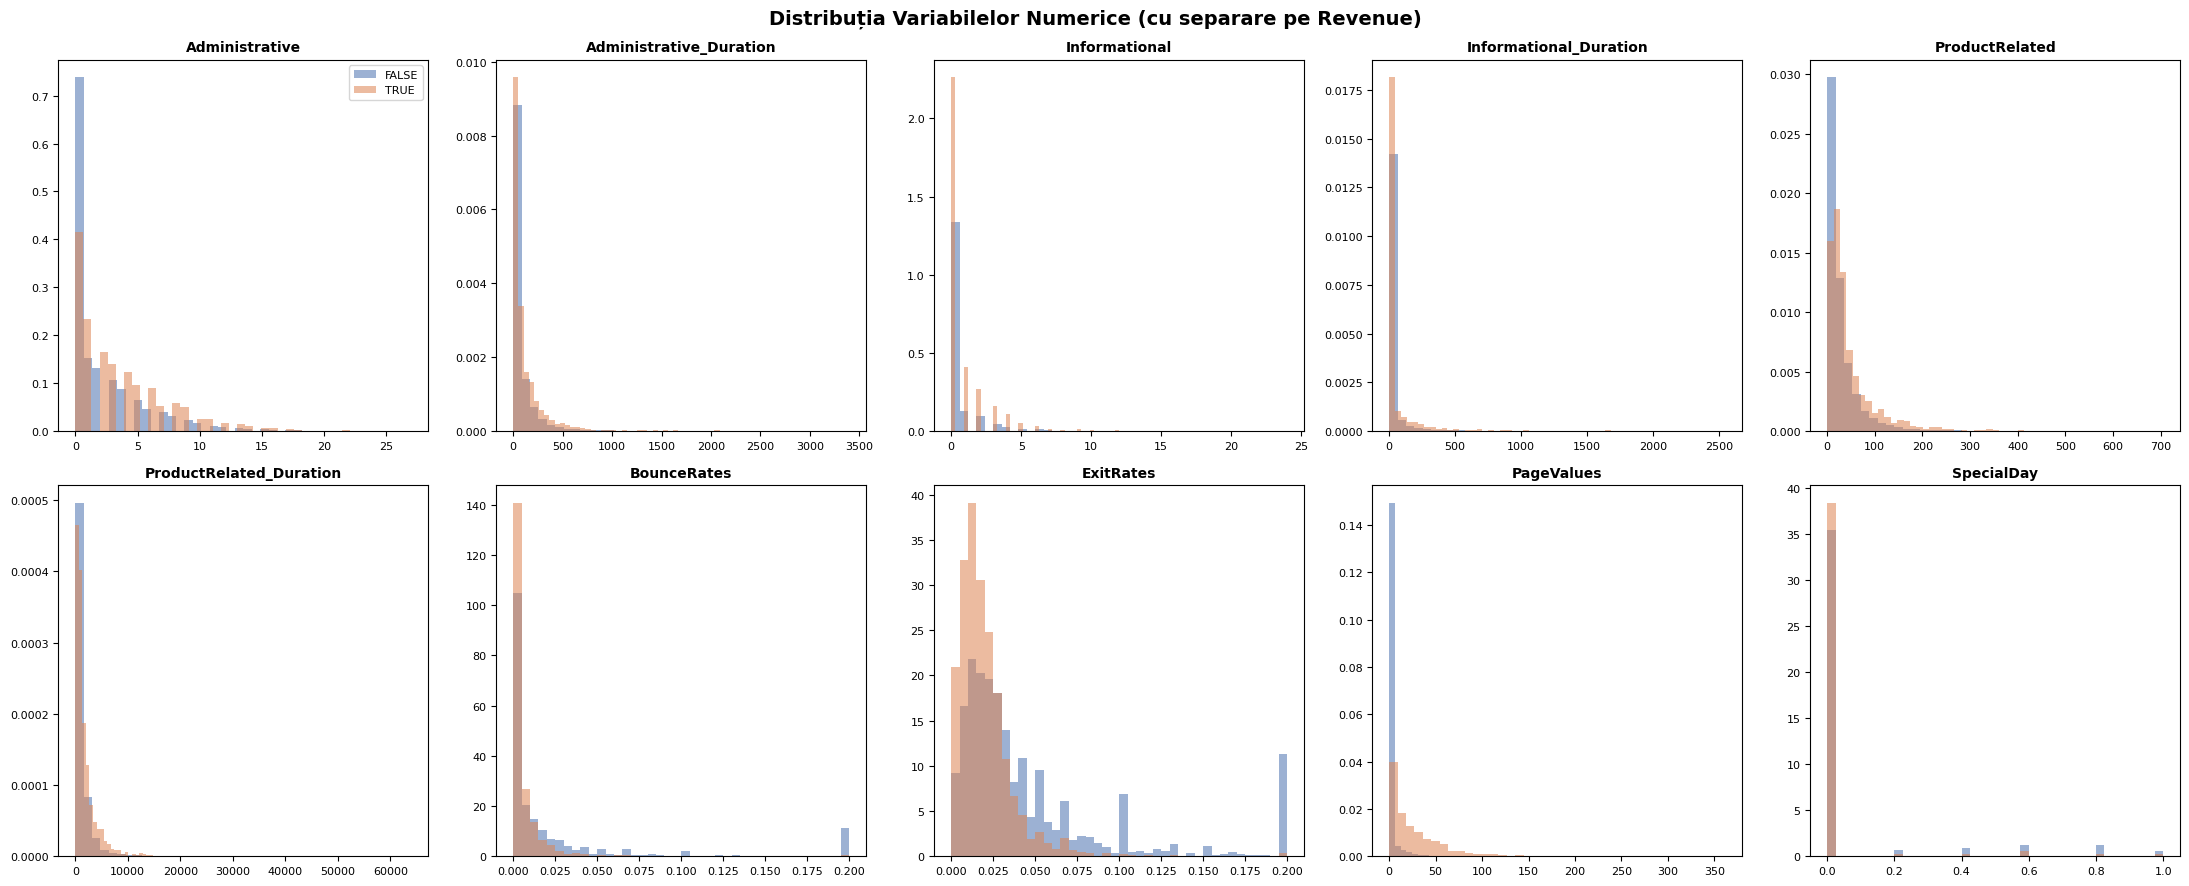

In [138]:
 
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Distribuția Variabilelor Numerice (cu separare pe Revenue)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    ax = axes[i]
    for val, color, label in [(False, '#4C72B0', 'FALSE'), (True, '#DD8452', 'TRUE')]:
        data = df[df['Revenue'] == val][col]
        ax.hist(data, bins=40, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)
 
plt.tight_layout()
plt.show()

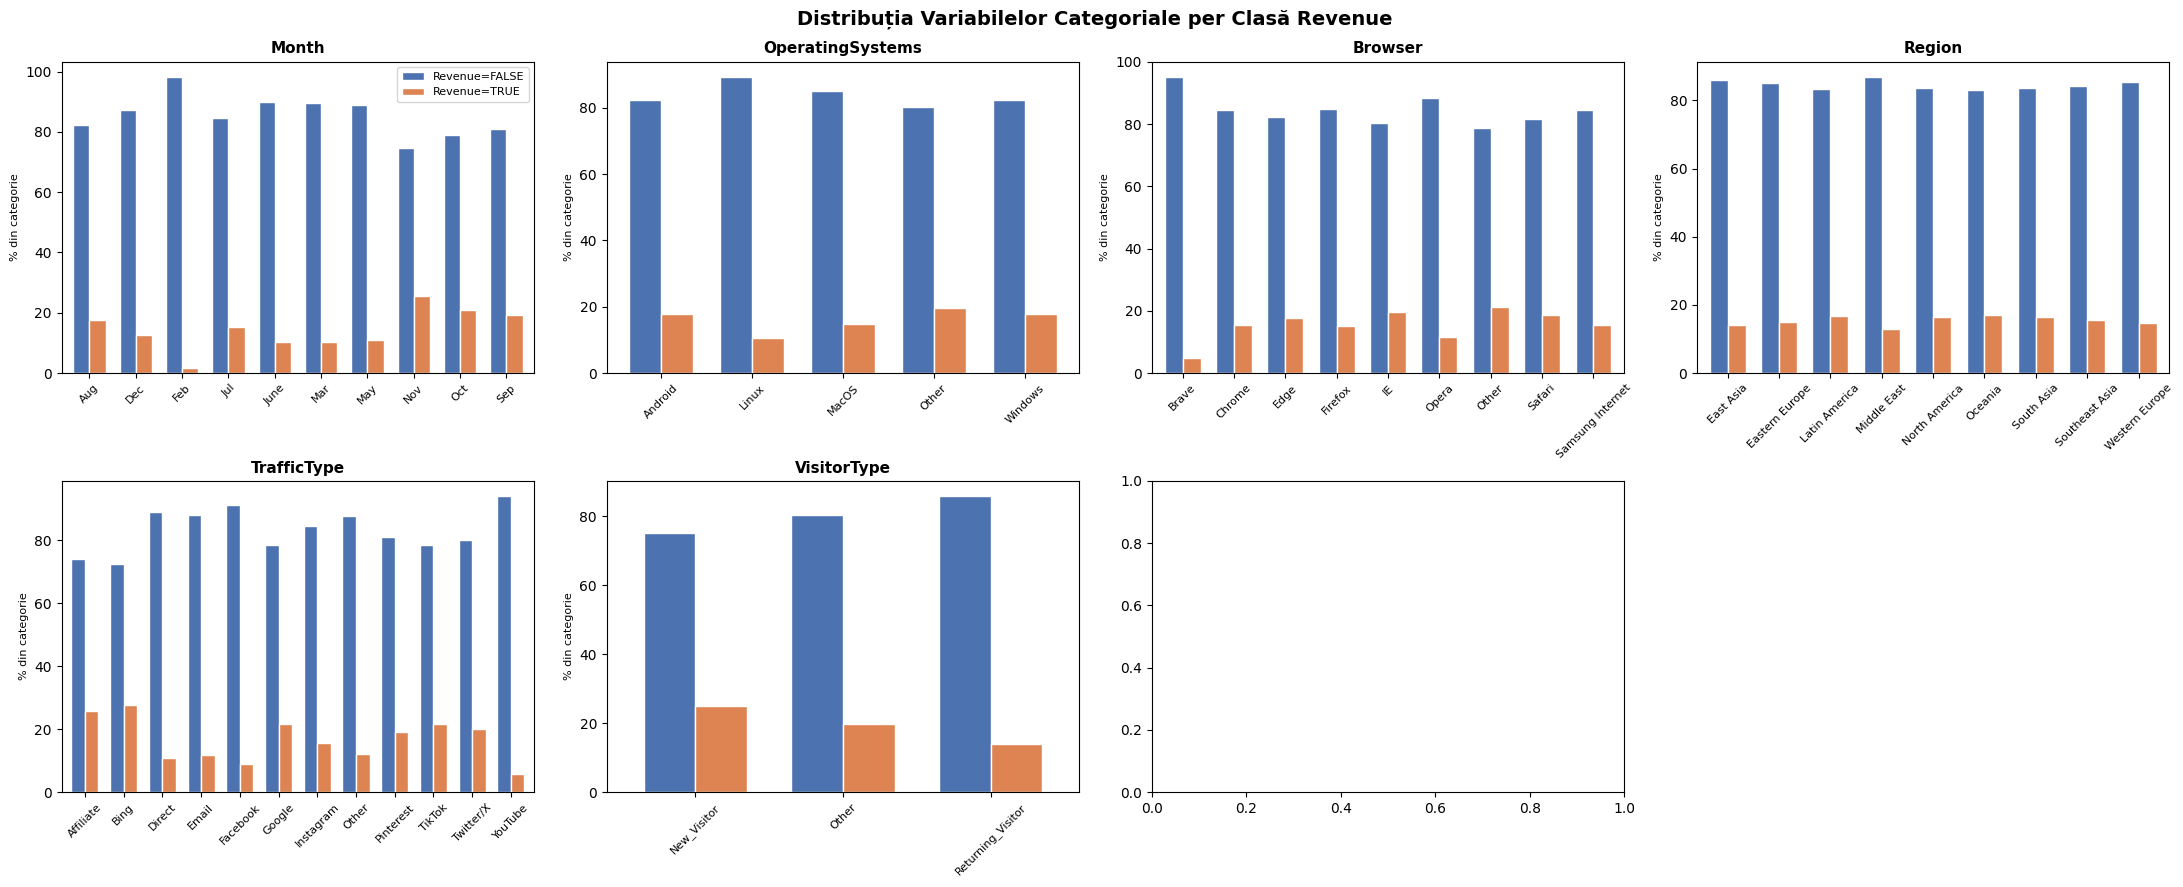

In [139]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Distribuția Variabilelor Categoriale per Clasă Revenue',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['Revenue'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white',
            width=0.7, legend=(i == 0))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% din categorie', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if i == 0:
        ax.legend(['Revenue=FALSE', 'Revenue=TRUE'], fontsize=8)
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

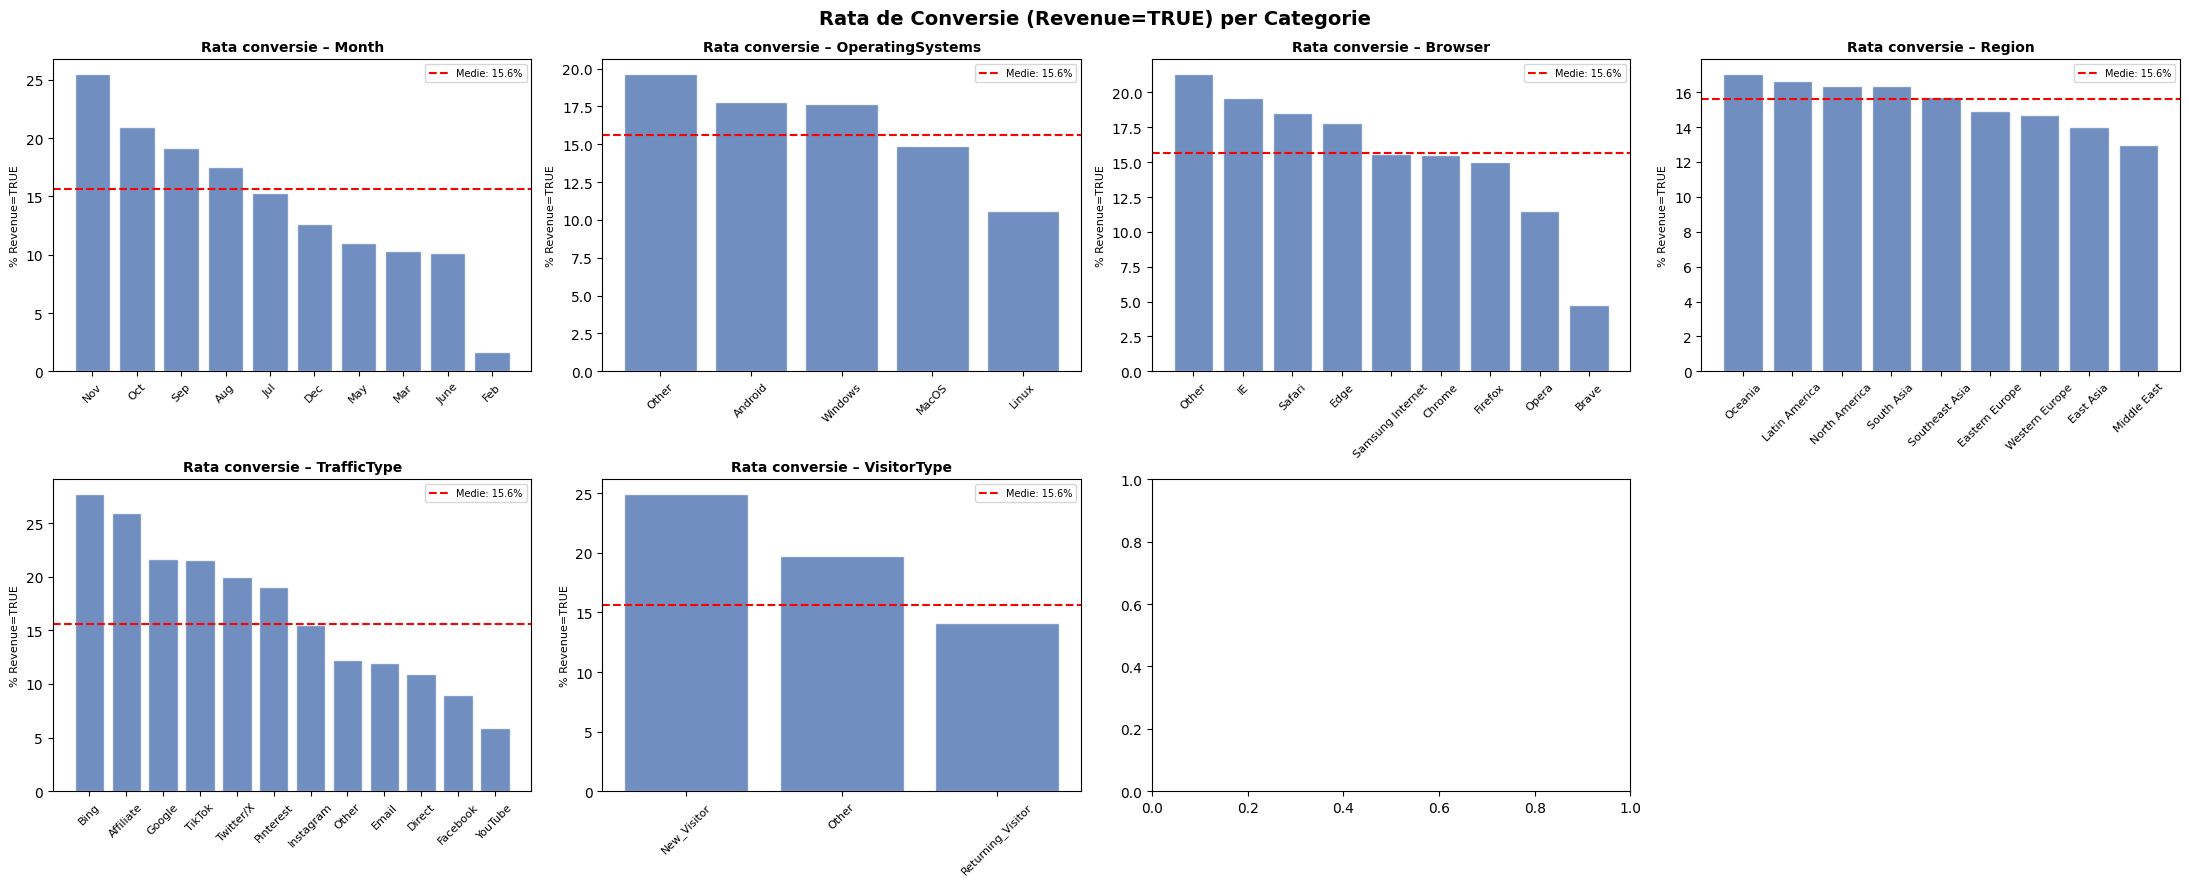

In [140]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Rata de Conversie (Revenue=TRUE) per Categorie',
             fontsize=14, fontweight='bold')
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    ax = axes[i]
    conv = df.groupby(col)['Revenue'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(conv.index.astype(str), conv.values,
                  color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.axhline(df['Revenue'].mean() * 100, color='red', linestyle='--',
               linewidth=1.5, label=f'Medie: {df["Revenue"].mean()*100:.1f}%')
    ax.set_title(f'Rata conversie – {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('% Revenue=TRUE', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=7)
 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Matricea de corelatie

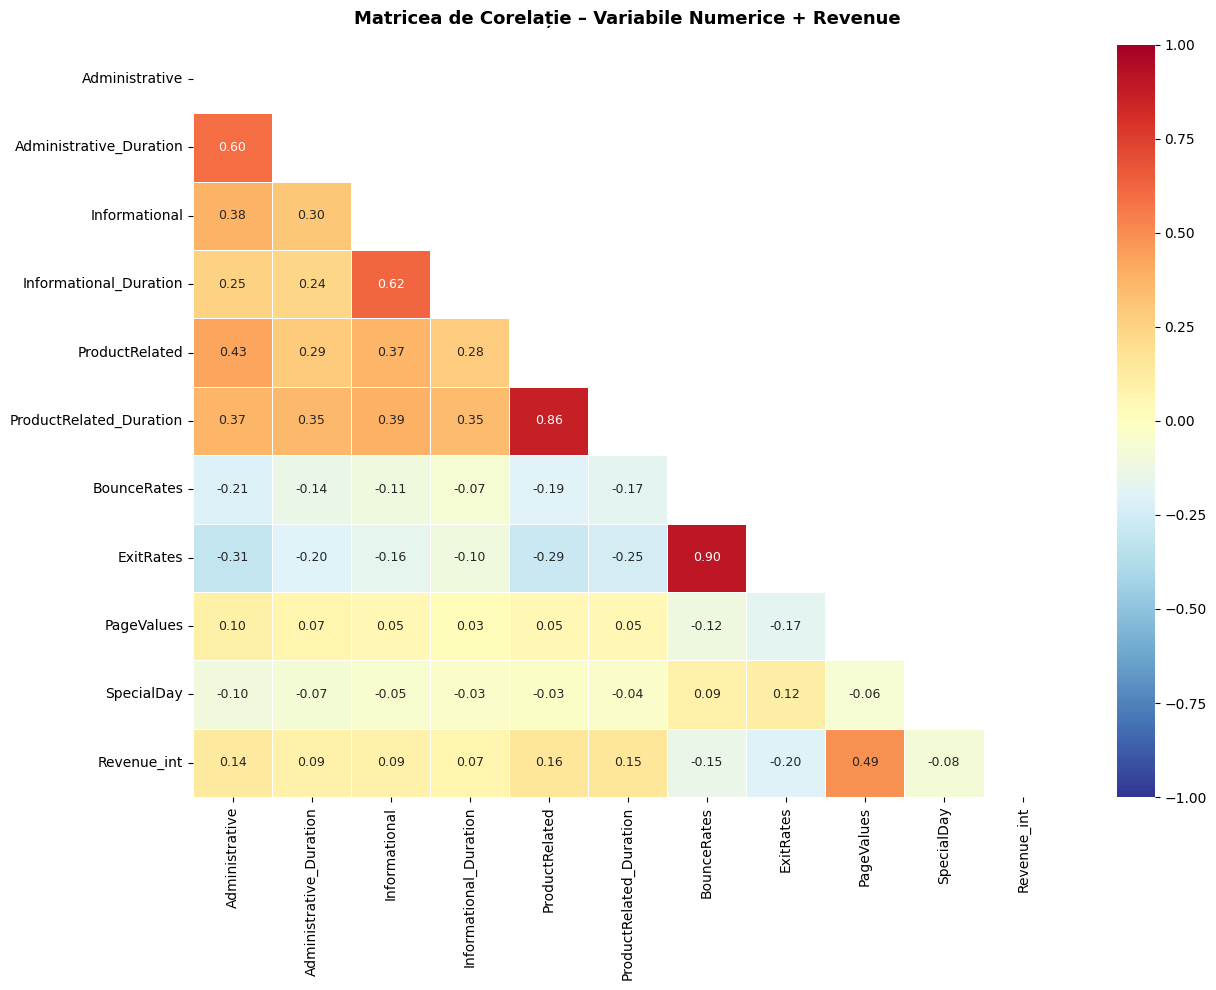

In [141]:
df_corr = df.copy()
df_corr['Revenue_int'] = df_corr['Revenue'].astype(int)
corr_matrix = df_corr[num_cols + ['Revenue_int']].corr()
 
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
ax.set_title('Matricea de Corelație – Variabile Numerice + Revenue',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

PageValues                 0.4919
ProductRelated             0.1560
ProductRelated_Duration    0.1501
Administrative             0.1363
Informational              0.0936
Administrative_Duration    0.0918
Informational_Duration     0.0694
SpecialDay                -0.0836
BounceRates               -0.1451
ExitRates                 -0.2043


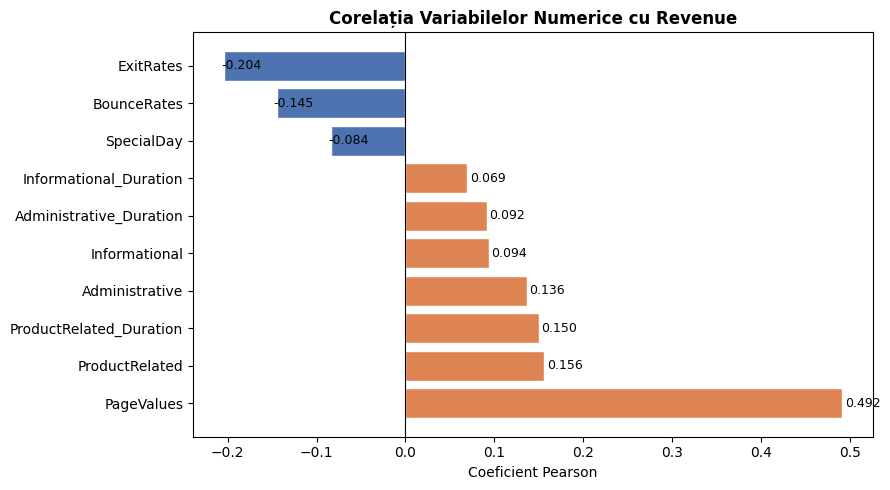

In [142]:
corr_target = corr_matrix['Revenue_int'].drop('Revenue_int').sort_values(ascending=False)
print(corr_target.round(4).to_string())
 
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DD8452' if x > 0 else '#4C72B0' for x in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corelația Variabilelor Numerice cu Revenue', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficient Pearson')
for i, (name, val) in enumerate(zip(corr_target.index, corr_target.values)):
    ax.text(val + 0.003 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [143]:
median_pv_false = df[df['Revenue'] == False]['PageValues'].median()
median_pv_true  = df[df['Revenue'] == True]['PageValues'].median()
print(f"Mediana PageValues | Revenue=FALSE: {median_pv_false}")
print(f"Mediana PageValues | Revenue=TRUE : {median_pv_true:.2f}")

Mediana PageValues | Revenue=FALSE: 0.0
Mediana PageValues | Revenue=TRUE : 16.76


-   PageValues este cel mai discriminant predictor

In [144]:
df_final.shape

(15445, 18)

In [145]:
df_final['Revenue'].value_counts()

Revenue
0    10297
1     5148
Name: count, dtype: int64

## Discretizare

In [146]:
## Discretizare PageValues
bins_pv   = [-0.001, 0, 10, 50, df_final['PageValues'].max() + 1]
labels_pv = ['Zero', 'Mic', 'Mediu', 'Mare']
df_final['PageValues_disc'] = pd.cut(df_final['PageValues'], bins=bins_pv, labels=labels_pv)

## Discretizare BounceRates
bins_br   = [-0.001, 0.01, 0.10, df_final['BounceRates'].max() + 0.001]
labels_br = ['Foarte Mic', 'Mediu', 'Mare']
df_final['BounceRates_disc'] = pd.cut(df_final['BounceRates'], bins=bins_br, labels=labels_br)

## Discretizare ExitRates
bins_er   = [-0.001, 0.02, 0.10, df_final['ExitRates'].max() + 0.001]
labels_er = ['Mic', 'Mediu', 'Mare']
df_final['ExitRates_disc'] = pd.cut(df_final['ExitRates'], bins=bins_er, labels=labels_er)

## Discretizare ProductRelated_Duration
q1 = df_final['ProductRelated_Duration'].quantile(0.33)
q2 = df_final['ProductRelated_Duration'].quantile(0.66)
bins_prd   = [-0.001, 0, q1, q2, df_final['ProductRelated_Duration'].max() + 1]
labels_prd = ['Zero', 'Scurt', 'Mediu', 'Lung']
df_final['ProductRelated_Duration_disc'] = pd.cut(df_final['ProductRelated_Duration'], bins=bins_prd, labels=labels_prd)

In [147]:
bins_ad   = [-0.001, 0, 60, 300, df['Administrative_Duration'].max() + 1]
labels_ad = ['Zero', 'Rapid (1-60s)', 'Mediu (1-5min)', 'Lung (>5min)']
df_final['Administrative_Duration_disc'] = pd.cut(
    df_final['Administrative_Duration'], bins=bins_ad, labels=labels_ad)

In [148]:
disc_summary = pd.DataFrame({
    'Variabilă originală': ['PageValues', 'BounceRates', 'ExitRates',
                             'ProductRelated_Duration', 'Administrative_Duration'],
    'Valori unice înainte': [df[c].nunique() for c in
                              ['PageValues', 'BounceRates', 'ExitRates',
                               'ProductRelated_Duration', 'Administrative_Duration']],
    'Tip înainte': ['Continuă'] * 5,
    'Valori după': [4, 3, 3, 4, 4],
    'Tip după': ['Ordinală'] * 5,
    'Categorii': [str(labels_pv), str(labels_br), str(labels_er),
                  str(labels_prd), str(labels_ad)]
})
print(disc_summary.to_string(index=False))

    Variabilă originală  Valori unice înainte Tip înainte  Valori după Tip după                                                   Categorii
             PageValues                  2704    Continuă            4 Ordinală                            ['Zero', 'Mic', 'Mediu', 'Mare']
            BounceRates                  1872    Continuă            3 Ordinală                             ['Foarte Mic', 'Mediu', 'Mare']
              ExitRates                  4777    Continuă            3 Ordinală                                    ['Mic', 'Mediu', 'Mare']
ProductRelated_Duration                  9551    Continuă            4 Ordinală                          ['Zero', 'Scurt', 'Mediu', 'Lung']
Administrative_Duration                  3335    Continuă            4 Ordinală ['Zero', 'Rapid (1-60s)', 'Mediu (1-5min)', 'Lung (>5min)']


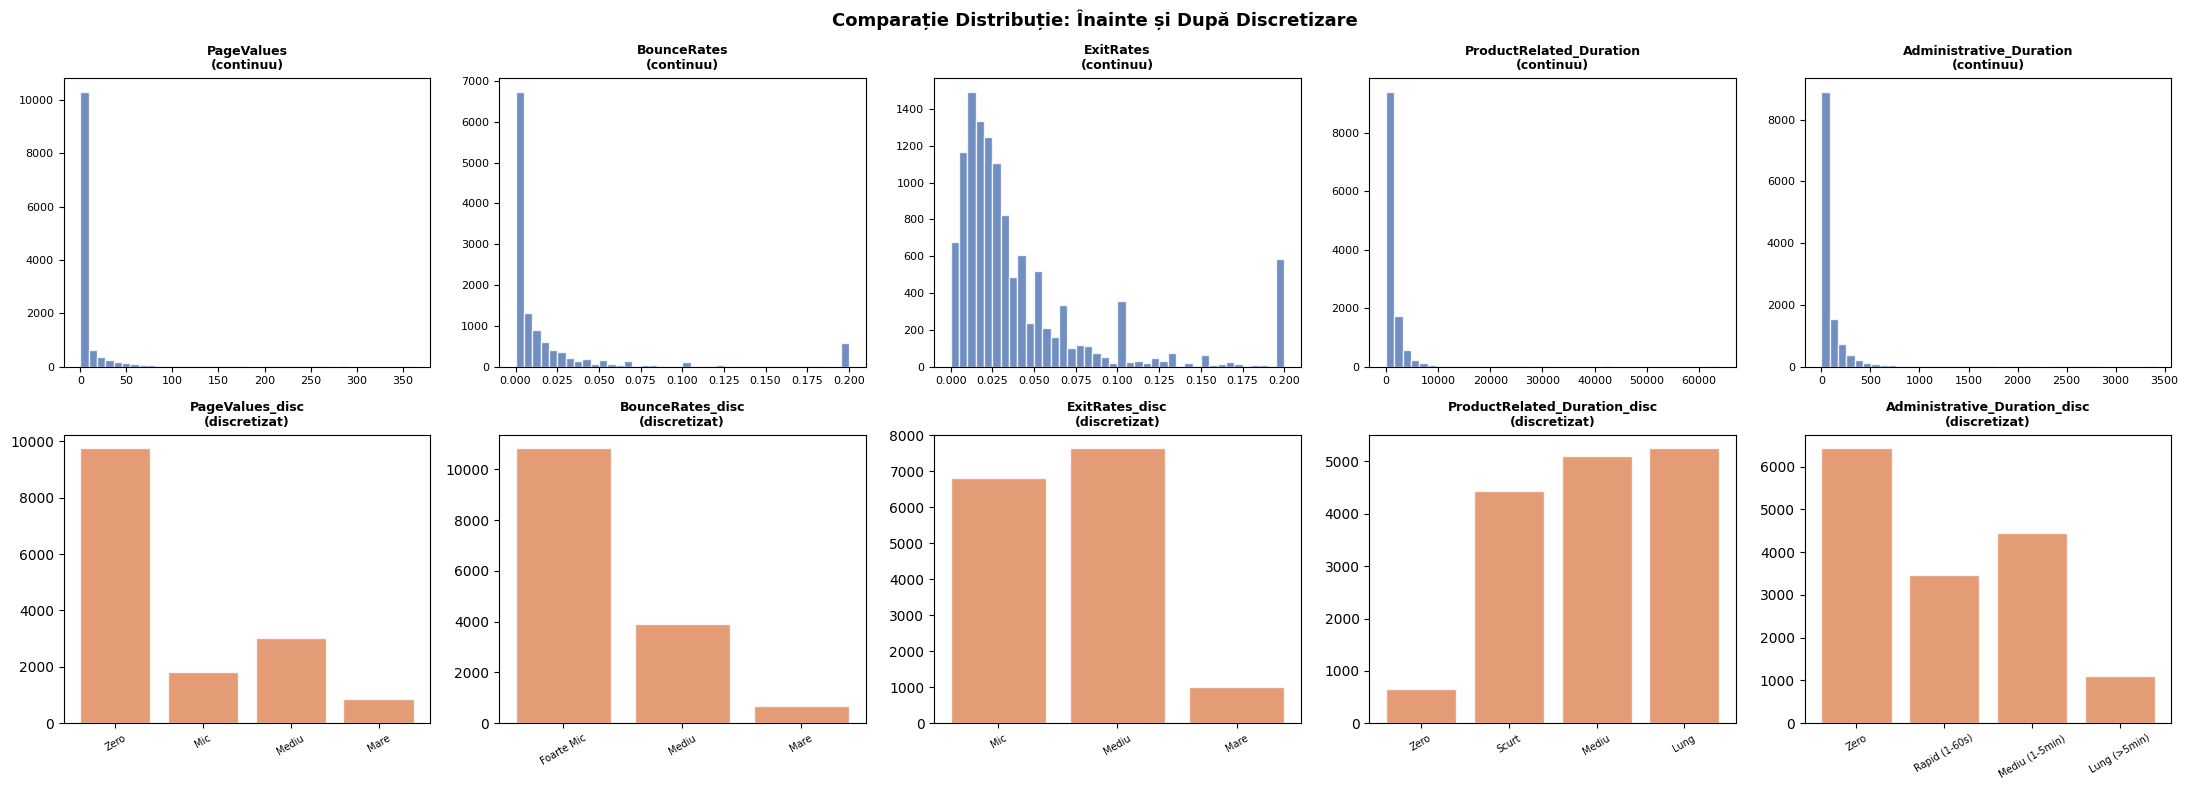

In [149]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Comparație Distribuție: Înainte și După Discretizare', fontsize=13, fontweight='bold')
 
orig_cols = ['PageValues', 'BounceRates', 'ExitRates',
             'ProductRelated_Duration', 'Administrative_Duration']
disc_cols = ['PageValues_disc', 'BounceRates_disc', 'ExitRates_disc',
             'ProductRelated_Duration_disc', 'Administrative_Duration_disc']
 
for i, (orig, disc) in enumerate(zip(orig_cols, disc_cols)):
    ax1 = axes[0][i]
    ax1.hist(df[orig].dropna(), bins=40, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax1.set_title(f'{orig}\n(continuu)', fontsize=9, fontweight='bold')
    ax1.tick_params(labelsize=8)
 
    ax2 = axes[1][i]
    vc = df_final[disc].value_counts().sort_index()
    ax2.bar(range(len(vc)), vc.values, color='#DD8452', alpha=0.8, edgecolor='white')
    ax2.set_xticks(range(len(vc)))
    ax2.set_xticklabels(vc.index.tolist(), rotation=30, fontsize=7)
    ax2.set_title(f'{disc}\n(discretizat)', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.show()

In [ ]:
print("Coloane disponibile:")
print(df_final.columns.tolist())

print(f"\nDimensiune: {df_final.shape}")
print(f"Revenue distribution:\n{df_final['Revenue'].value_counts()}")
print(f"\nValori lipsă: {df_final.isnull().sum().sum()}")

Coloane disponibile:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue', 'PageValues_disc', 'BounceRates_disc', 'ExitRates_disc', 'ProductRelated_Duration_disc', 'Administrative_Duration_disc']

Dimensiune: (15445, 23)
Revenue distribution:
Revenue
0    10297
1     5148
Name: count, dtype: int64

Valori lipsă: 0


In [ ]:
print(df_final['Weekend'].dtype)
print(df_final['Weekend'].unique())

int64
[0 1]


In [152]:
df_final.to_csv('../../data/processed/online_shoppers_final.csv', index=False)